# Analysis: Did Year 10 Depart from the Baseline Trend?

For each event type (severe thunderstorm **SV**, flash flood **FF**, tornado **TO**) and each of three metrics (**POD** detection, **FAR** false alarms, **lead time**), this notebook tests whether year 10 (2025) departs from the season-adjusted baseline trend fit over years 1 to 9 (2016 to 2024). The three event types are analyzed separately and never pooled. That is **nine separate questions and nine model fits**.

## The quantity of interest

Every model uses the same right-hand side, fit on all ten years:

```
C(season_cat) + study_year + is_year10
```

- `C(season_cat)` absorbs the season-of-year pattern (Spring/Summer/Fall/Winter).
- `study_year` (numeric, 1 to 10) absorbs any baseline drift across years 1 to 9.
- `is_year10` (integer 0/1, 1 only for year 10) is **the quantity of interest**: how far year 10 departs from the season-adjusted baseline trend. Its coefficient, p-value, and confidence interval answer the research question directly.

This is not a flat baseline-versus-year-10 comparison. The `study_year` trend is what "departure" is measured against.

## The three models (per event type)

1. **Detection (POD)** - logistic regression on storm-report rows; outcome `warned` (was the observed event warned).
2. **False alarms (FAR)** - logistic regression on warning rows; outcome `false_alarm` (1 = the warning did not verify, i.e. it was a false alarm). FAR is the complement of the verification rate, `false_alarm = 1 - verify`, fit directly so the odds ratio is on the false-alarm scale.
3. **Lead time in advance (LTA)** - OLS on warned storm reports only; outcome `leadtime` in minutes.

## Workflow, per metric per event type

1. Plot the raw yearly rate (or mean lead time) before any modeling.
2. **Drift check**: fit `C(season_cat) + study_year` on years 1 to 9 only; inspect the `study_year` slope (diagnostic, not the test).
3. **Main test**: fit the full model on all ten years; read `is_year10` (odds ratio for logistic, minutes for OLS).
4. Report magnitude and uncertainty, not just a p-value.

## Placebo (falsification) test

Drop year 10, then for interior baseline years substitute a fake `is_placebo` indicator into the same model. If the machinery flags an innocent year as readily as it flags year 10, the year-10 result cannot be trusted. With nine baseline years this is a rough credibility check, not a formal null.

## What this is, and is not

The finding is **associational**: a before/after observational comparison, not a controlled experiment. It establishes whether a metric changed, not why. It does **not** identify a cause such as staffing; no reliable per-office staffing data was available. LSRs are imperfect ground truth, the three metrics must be read together, storm clustering challenges independence, nine baseline years is few points, and nine tests inflate false positives. These cautions are carried through to the written interpretation.

## Setup and data load

Load the two cleaned tables and restrict to the contiguous United States (CONUS) by dropping the non-CONUS Weather Forecast Offices (WFOs). The cleaning step already derived the model-ready columns (`season_cat`, `study_year`, `is_year10`) and cast the binary outcomes (`warned`, `verify`) to integer 0/1, so this notebook consumes them directly.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

import sys
sys.path.insert(0, str(Path.cwd().parent))

from src.analysis import data, stats, plots
from src.analysis.constants import NON_CONUS, PHENOMENA_LABELS

CLEAN_DIR = Path.cwd().parent / "data" / "03_cleaning"
IMG_DIR = Path.cwd().parent / "img"

stormreports = data.load_stormreports(CLEAN_DIR)
events = data.load_events(CLEAN_DIR)

# CONUS scope: drop non-CONUS WFOs inline (the analysis footprint is the lower 48 + DC).
stormreports = stormreports[~stormreports["wfo"].isin(NON_CONUS)].copy()
events = events[~events["wfo"].isin(NON_CONUS)].copy()

print(f"storm reports (CONUS): {len(stormreports):,} rows")
print(f"events       (CONUS): {len(events):,} rows")

storm reports (CONUS): 376,963 rows
events       (CONUS): 260,537 rows


### Validate the modeled columns

Before fitting, fail loudly on anything that would corrupt a fit: binary outcomes must be integer 0/1, `study_year` numeric, `season_cat` text, and no missing values in any modeled column. The cleaning step is supposed to guarantee this; the assertions confirm it on the loaded data rather than trusting it.

In [2]:
def validate_modeled(df, outcome_col, kind, name):
    """Assert the modeled columns are fit-ready; raise on the first violation."""
    cols = [outcome_col, "season_cat", "study_year", "is_year10"]
    na = df[cols].isna().sum()
    assert na.sum() == 0, f"{name}: NaNs in modeled columns:\n{na[na > 0]}"
    assert pd.api.types.is_numeric_dtype(df["study_year"]), f"{name}: study_year not numeric"
    assert set(df["is_year10"].unique()) <= {0, 1}, f"{name}: is_year10 not 0/1"
    if kind == "logit":
        vals = set(df[outcome_col].unique())
        assert vals <= {0, 1}, f"{name}: {outcome_col} not 0/1, has {vals}"
    # season_cat carries the four season labels as text, not the YYYY-Season period id.
    assert pd.api.types.is_string_dtype(df["season_cat"]), f"{name}: season_cat not text"
    print(f"{name}: OK  ({len(df):,} rows, study_year {df['study_year'].min()}-{df['study_year'].max()})")

validate_modeled(stormreports, "warned", "logit", "storm reports / warned")
validate_modeled(events, "verify", "logit", "events / verify")
validate_modeled(stormreports[stormreports["warned"] == 1], "leadtime", "ols", "warned reports / leadtime")

storm reports / warned: OK  (376,963 rows, study_year 1-10)
events / verify: OK  (260,537 rows, study_year 1-10)
warned reports / leadtime: OK  (287,832 rows, study_year 1-10)


---

# Tornado (TO)

The three metrics for tornado events, each fit separately. Tornado storm reports drive the detection (POD) and lead-time models; tornado warnings drive the false-alarm (FAR) model. The subset below is the only place the event-type filter is applied; every fit in this section reads from it.

The pre-modeling estimability gate (per-`season_cat` cell counts and 0%/100% separation checks) ran in `04_eda` over all nine fits and passed; it is not repeated here.

In [3]:
TYPE = "TO"

to_reports = stormreports[stormreports["lsrtype"] == TYPE]
to_events = events[events["phenomena"] == TYPE]
to_warned = to_reports[to_reports["warned"] == 1]

print(f"{PHENOMENA_LABELS[TYPE]}:")
print(f"  storm reports : {len(to_reports):,}  (POD model)")
print(f"  warnings      : {len(to_events):,}  (FAR model)")
print(f"  warned reports: {len(to_warned):,}  (lead-time model)")

Tornado:
  storm reports : 17,510  (POD model)
  warnings      : 25,817  (FAR model)
  warned reports: 11,217  (lead-time model)


## Probability of Detection (POD)

Logistic regression on tornado storm reports; outcome `warned` (was the observed tornado warned). First the drift check on baseline years 1 to 9 (`study_year` slope, diagnostic), then the main test on all ten years. The `is_year10` term, exponentiated to an odds ratio, is the quantity of interest: the year-10 departure from the season-adjusted baseline trend. Results are collected into `RESULTS` for the cross-cutting nine-test table and multiple-comparison correction later.

In [4]:
# Accumulator for the nine year-10 tests (filled as each metric is fit).
RESULTS = []

def report_fit(event_type, metric, df, outcome, kind):
    """Fit drift + main model, print a readable summary, and record the year-10 term."""
    drift = stats.fit_drift(df, outcome, kind)
    main = stats.fit_main_model(df, outcome, kind)
    scale = "log-odds" if kind == "logit" else "minutes"
    print(f"{event_type} {metric}  (n={main['n']:,})")
    print(f"  drift  study_year slope = {drift['slope']:+.4f} {scale}/yr "
          f"[{drift['ci_low']:+.4f}, {drift['ci_high']:+.4f}]  p={drift['p']:.4f}")
    print(f"  YEAR10 is_year10 coef   = {main['coef']:+.4f} {scale} "
          f"[{main['ci_low']:+.4f}, {main['ci_high']:+.4f}]  p={main['p']:.4f} {stats.sig_stars(main['p'])}")
    if kind == "logit":
        print(f"         odds ratio       = {main['or_']:.3f} "
              f"[{main['or_low']:.3f}, {main['or_high']:.3f}]")
    RESULTS.append({"event_type": event_type, "metric": metric, "kind": kind,
                    "n": main["n"], "drift_slope": drift["slope"],
                    "coef": main["coef"], "se": main["se"], "ci_low": main["ci_low"],
                    "ci_high": main["ci_high"], "p": main["p"],
                    "or": main.get("or_", np.nan)})
    return main

_ = report_fit("TO", "POD", to_reports, "warned", "logit")

TO POD  (n=17,510)
  drift  study_year slope = +0.0231 log-odds/yr [+0.0105, +0.0357]  p=0.0003
  YEAR10 is_year10 coef   = +0.0869 log-odds [-0.0365, +0.2103]  p=0.1675 ns
         odds ratio       = 1.091 [0.964, 1.234]


### TO POD year-10 departure

The detection rate per baseline year (1 to 9), the season-adjusted trend fit on those years and extrapolated to year 10, and the actual year-10 rate. The dotted connector is the departure the test quantifies. The figure is on the rate scale for readability; the formal test above is on the odds-ratio scale and is not numerically identical.

year-10 actual=0.6887  trend@10=0.6606  gap=+0.0281


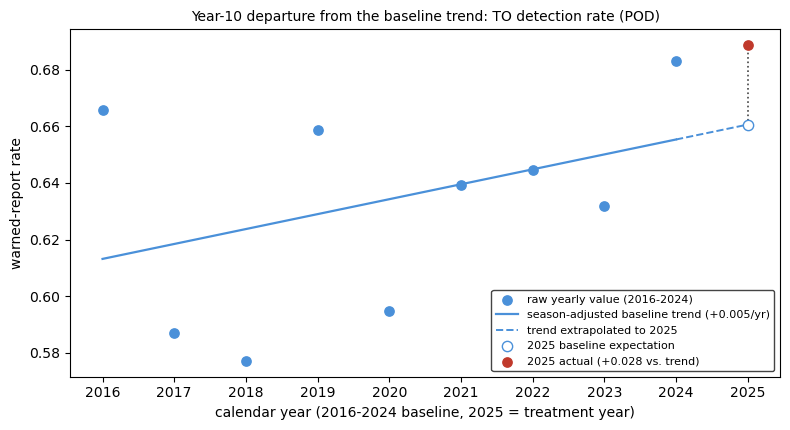

In [5]:
def year10_inputs(df, outcome, agg="mean"):
    """Per-year baseline series (1-9), baseline trend, and the year-10 actual."""
    yearly = df[df["study_year"] < 10].groupby("study_year")[outcome].agg(agg)
    trend = stats.season_adjusted_trend(df, outcome)
    y10 = df[df["study_year"] == 10][outcome].agg(agg)
    return yearly, trend, float(y10)

_y, _tr, _a = year10_inputs(to_reports, "warned")
_d = stats.departure_summary(_tr, _a)
print(f"year-10 actual={_d['actual']:.4f}  trend@10={_d['trend_at_10']:.4f}  gap={_d['gap']:+.4f}")
plots.plot_year10_departure(_y, _tr, _a, "TO", "TO detection rate (POD)",
                            "warned-report rate", "pod_to", IMG_DIR)

*The year-10 detection rate sits modestly above the extrapolated baseline trend, but the gap is small relative to the year-to-year scatter of the baseline points. This matches the non-significant test (odds ratio 1.09, p = 0.17): no clear year-10 departure in tornado detection.*

### TO POD placebo

The real year-10 effect against the spread of placebo effects from interior baseline years (year 10 dropped, a fake indicator substituted into each). If the real effect sits inside the placebo cloud, the method flags innocent years as readily as year 10. With only a handful of placebo years this is a rough credibility check, not a formal null.

real=+0.0869  placebo spread=[-0.1821, +0.1608]  inside=True  placebo hits=4/7


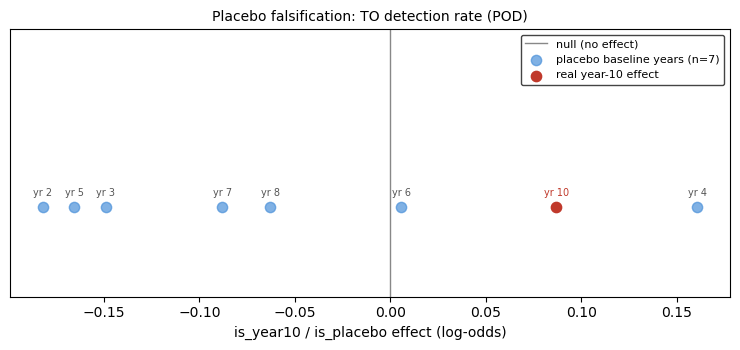

In [6]:
_pl = stats.run_placebo(to_reports, "warned", "logit")
_real = next(r for r in RESULTS if r["event_type"] == "TO" and r["metric"] == "POD")
_ps = stats.placebo_summary(_pl, _real["coef"])
print(f"real={_ps['real_coef']:+.4f}  placebo spread=[{_ps['lo']:+.4f}, {_ps['hi']:+.4f}]  "
      f"inside={_ps['inside']}  placebo hits={_ps['n_sig']}/{_ps['n']}")
plots.plot_placebo(_pl, _real["coef"], "TO", "TO detection rate (POD)",
                   "is_year10 / is_placebo effect (log-odds)", "pod_to", IMG_DIR)

*The real year-10 effect sits inside the spread of placebo effects from innocent baseline years, with at least one placebo year showing a larger swing. The method flags ordinary baseline years about as readily as it flags year 10, so the year-10 detection result should not be read as special. This is consistent with the lumpy tornado baseline noted earlier.*

## False Alarm Ratio (FAR)

Logistic regression on tornado warnings; outcome `false_alarm` (1 = the warning did not verify against an observed event, i.e. it was a false alarm). FAR is the complement of the verification rate, `false_alarm = 1 - verify`, and the model fits it directly so the coefficient and odds ratio are on the false-alarm scale the metric is named for. A higher FAR means more false alarms. Same drift-then-main structure; the `is_year10` odds ratio is the year-10 departure in false-alarm odds from the baseline trend.

In [7]:
_ = report_fit("TO", "FAR", to_events, "false_alarm", "logit")

TO FAR  (n=25,817)
  drift  study_year slope = -0.0027 log-odds/yr [-0.0140, +0.0086]  p=0.6392
  YEAR10 is_year10 coef   = +0.0307 log-odds [-0.0713, +0.1327]  p=0.5552 ns
         odds ratio       = 1.031 [0.931, 1.142]


### TO FAR year-10 departure

The false-alarm rate (FAR) per baseline year, the season-adjusted trend extrapolated to year 10, and the actual year-10 FAR. A higher rate means more false alarms. Rate scale for readability; the test above is on the odds-ratio scale.

year-10 actual=0.7312  trend@10=0.7379  gap=-0.0067


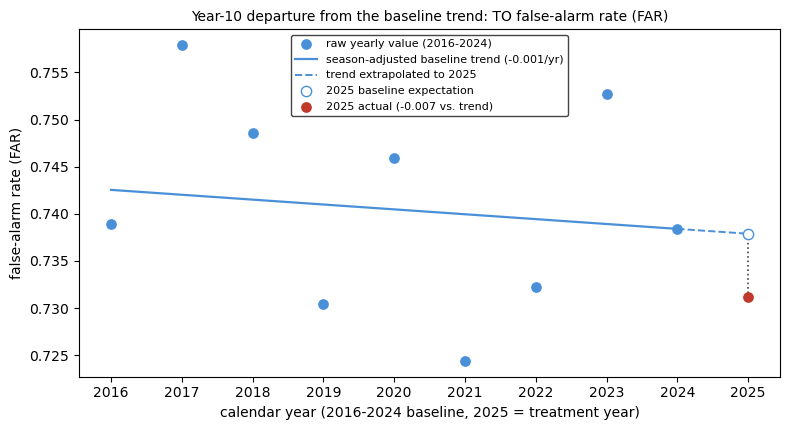

In [8]:
_y, _tr, _a = year10_inputs(to_events, "false_alarm")
_d = stats.departure_summary(_tr, _a)
print(f"year-10 actual={_d['actual']:.4f}  trend@10={_d['trend_at_10']:.4f}  gap={_d['gap']:+.4f}")
plots.plot_year10_departure(_y, _tr, _a, "TO", "TO false-alarm rate (FAR)",
                            "false-alarm rate (FAR)", "far_to", IMG_DIR)

*The year-10 false-alarm rate falls essentially on the extrapolated baseline trend (gap -0.007), with no visible departure. This matches the non-significant test (odds ratio 1.03, p = 0.56): no evidence of a year-10 change in tornado false-alarm performance.*

### TO FAR placebo

The real year-10 verify-rate effect against the placebo spread from interior baseline years.

real=+0.0307  placebo spread=[-0.1133, +0.1012]  inside=True  placebo hits=1/7


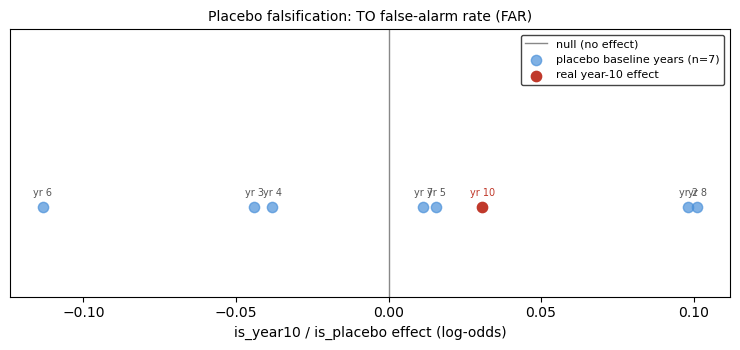

In [9]:
_pl = stats.run_placebo(to_events, "false_alarm", "logit")
_real = next(r for r in RESULTS if r["event_type"] == "TO" and r["metric"] == "FAR")
_ps = stats.placebo_summary(_pl, _real["coef"])
print(f"real={_ps['real_coef']:+.4f}  placebo spread=[{_ps['lo']:+.4f}, {_ps['hi']:+.4f}]  "
      f"inside={_ps['inside']}  placebo hits={_ps['n_sig']}/{_ps['n']}")
plots.plot_placebo(_pl, _real["coef"], "TO", "TO false-alarm rate (FAR)",
                   "is_year10 / is_placebo effect (log-odds)", "far_to", IMG_DIR)

*The real year-10 effect is tiny and sits just past the edge of the placebo spread, but the test itself is non-significant (odds ratio 1.03, p = 0.56) and the placebo years scatter on both sides of zero. There is no distinctive year-10 signal in tornado false alarms; the marginal placement reflects how small and noisy all these effects are, not a real departure.*

## Lead time in advance (LTA)

Ordinary least squares (OLS) on warned tornado reports only; outcome `leadtime` in minutes. Lead time is conditional on detection, so this model sees only the events that were warned. The `is_year10` coefficient is already in minutes: the year-10 change in mean lead time relative to the season-adjusted baseline trend.

In [10]:
_ = report_fit("TO", "LTA", to_warned, "leadtime", "ols")

TO LTA  (n=11,217)
  drift  study_year slope = +0.1523 minutes/yr [+0.0656, +0.2390]  p=0.0006
  YEAR10 is_year10 coef   = -0.5951 minutes [-1.4013, +0.2110]  p=0.1479 ns


### TO LTA year-10 departure

Mean lead time (minutes) per baseline year, the season-adjusted trend extrapolated to year 10, and the actual year-10 mean. Here both the figure and the OLS test are in minutes, so the drawn departure matches the test coefficient directly.

year-10 actual=15.550  trend@10=15.881  gap=-0.331 min


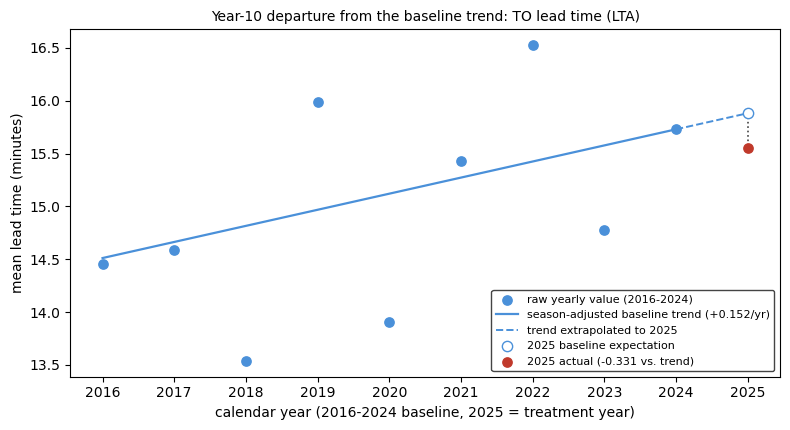

In [11]:
_y, _tr, _a = year10_inputs(to_warned, "leadtime")
_d = stats.departure_summary(_tr, _a)
print(f"year-10 actual={_d['actual']:.3f}  trend@10={_d['trend_at_10']:.3f}  gap={_d['gap']:+.3f} min")
plots.plot_year10_departure(_y, _tr, _a, "TO", "TO lead time (LTA)",
                            "mean lead time (minutes)", "lta_to", IMG_DIR)

*Mean lead time drifted upward across the baseline (+0.15 minutes per year). The year-10 actual falls slightly below the extrapolated trend, but the gap is small and within the baseline scatter, matching the non-significant test (-0.60 minutes, p = 0.15). No clear year-10 departure in tornado lead time. Note that lead time is conditional on detection, so a shift in which events were warned can move this mean independently of timeliness.*

### TO LTA placebo

The real year-10 lead-time effect (minutes) against the placebo spread from interior baseline years.

real=-0.595  placebo spread=[-1.357, +1.188] min  inside=True  placebo hits=5/7


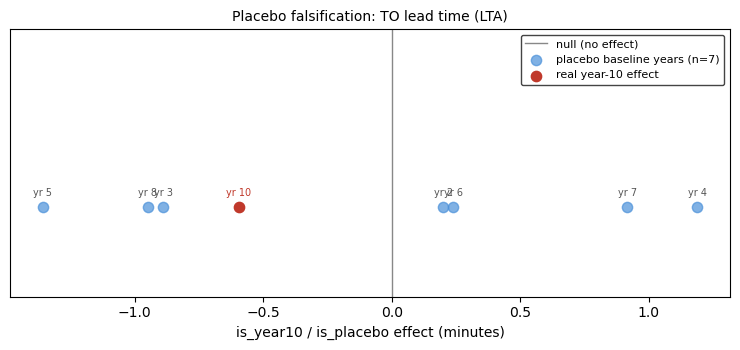

In [12]:
_pl = stats.run_placebo(to_warned, "leadtime", "ols")
_real = next(r for r in RESULTS if r["event_type"] == "TO" and r["metric"] == "LTA")
_ps = stats.placebo_summary(_pl, _real["coef"])
print(f"real={_ps['real_coef']:+.3f}  placebo spread=[{_ps['lo']:+.3f}, {_ps['hi']:+.3f}] min  "
      f"inside={_ps['inside']}  placebo hits={_ps['n_sig']}/{_ps['n']}")
plots.plot_placebo(_pl, _real["coef"], "TO", "TO lead time (LTA)",
                   "is_year10 / is_placebo effect (minutes)", "lta_to", IMG_DIR)

*The real year-10 lead-time effect sits within the placebo spread, consistent with the departure figure: no distinctive year-10 signal in tornado lead time.*

---

# Severe Thunderstorm (SV)

The three metrics for severe thunderstorm events, each fit separately. Severe-storm storm reports drive the detection (POD) and lead-time models; severe-storm warnings drive the false-alarm (FAR) model. The subset below is the only place the event-type filter is applied; every fit in this section reads from it.

The pre-modeling estimability gate (per-`season_cat` cell counts and 0%/100% separation checks) ran in `04_eda` over all nine fits and passed; it is not repeated here.

In [13]:
TYPE = "SV"

sv_reports = stormreports[stormreports["lsrtype"] == TYPE]
sv_events = events[events["phenomena"] == TYPE]
sv_warned = sv_reports[sv_reports["warned"] == 1]

print(f"{PHENOMENA_LABELS[TYPE]}:")
print(f"  storm reports : {len(sv_reports):,}  (POD model)")
print(f"  warnings      : {len(sv_events):,}  (FAR model)")
print(f"  warned reports: {len(sv_warned):,}  (lead-time model)")

Severe Thunderstorm:
  storm reports : 305,167  (POD model)
  warnings      : 195,892  (FAR model)
  warned reports: 234,086  (lead-time model)


## Probability of Detection (POD)

Logistic regression on severe-storm storm reports; outcome `warned` (was the observed event warned). First the drift check on baseline years 1 to 9 (`study_year` slope, diagnostic), then the main test on all ten years. The `is_year10` term, exponentiated to an odds ratio, is the quantity of interest: the year-10 departure from the season-adjusted baseline trend. Results are appended to `RESULTS` for the cross-cutting nine-test table later.

In [14]:
_ = report_fit("SV", "POD", sv_reports, "warned", "logit")

SV POD  (n=305,167)
  drift  study_year slope = +0.0110 log-odds/yr [+0.0076, +0.0144]  p=0.0000
  YEAR10 is_year10 coef   = +0.0146 log-odds [-0.0171, +0.0463]  p=0.3663 ns
         odds ratio       = 1.015 [0.983, 1.047]


### SV POD year-10 departure

The detection rate per baseline year (1 to 9), the season-adjusted trend fit on those years and extrapolated to year 10, and the actual year-10 rate. The dotted connector is the departure the test quantifies. The figure is on the rate scale for readability; the formal test above is on the odds-ratio scale and is not numerically identical.

year-10 actual=0.7817  trend@10=0.7746  gap=+0.0071


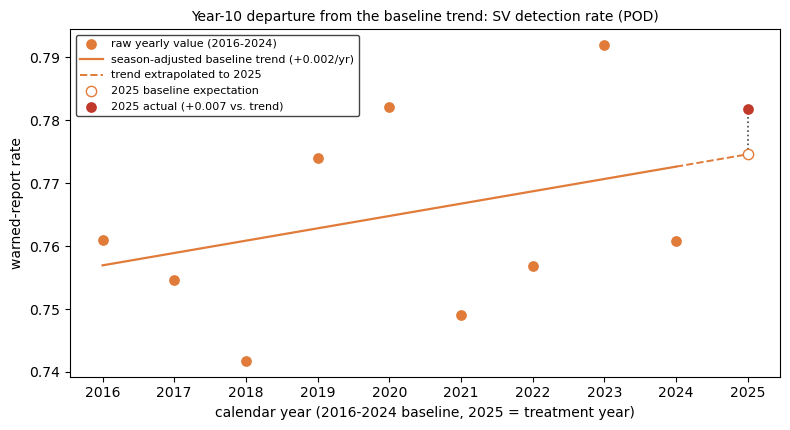

In [15]:
_y, _tr, _a = year10_inputs(sv_reports, "warned")
_d = stats.departure_summary(_tr, _a)
print(f"year-10 actual={_d['actual']:.4f}  trend@10={_d['trend_at_10']:.4f}  gap={_d['gap']:+.4f}")
plots.plot_year10_departure(_y, _tr, _a, "SV", "SV detection rate (POD)",
                            "warned-report rate", "pod_sv", IMG_DIR)

*The year-10 detection rate (0.782) sits just above the extrapolated baseline trend (0.775), a gap of +0.007 that is negligible against the year-to-year scatter. This matches the non-significant test (odds ratio 1.02, p = 0.37): no year-10 departure in severe-storm detection.*

### SV POD placebo

The real year-10 effect against the spread of placebo effects from interior baseline years (year 10 dropped, a fake indicator substituted into each). If the real effect sits inside the placebo cloud, the method flags innocent years as readily as year 10. With only a handful of placebo years this is a rough credibility check, not a formal null.

real=+0.0146  placebo spread=[-0.1195, +0.1724]  inside=True  placebo hits=7/7


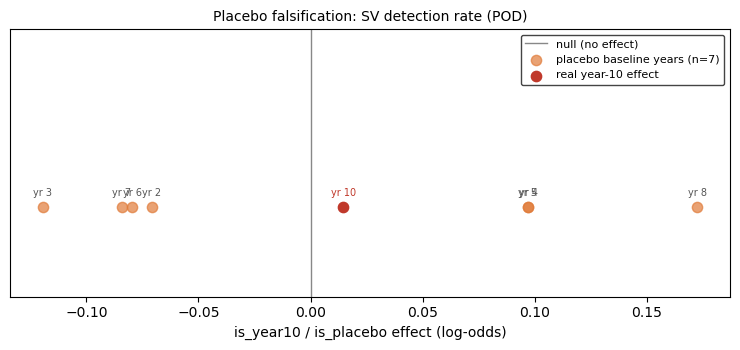

In [16]:
_pl = stats.run_placebo(sv_reports, "warned", "logit")
_real = next(r for r in RESULTS if r["event_type"] == "SV" and r["metric"] == "POD")
_ps = stats.placebo_summary(_pl, _real["coef"])
print(f"real={_ps['real_coef']:+.4f}  placebo spread=[{_ps['lo']:+.4f}, {_ps['hi']:+.4f}]  "
      f"inside={_ps['inside']}  placebo hits={_ps['n_sig']}/{_ps['n']}")
plots.plot_placebo(_pl, _real["coef"], "SV", "SV detection rate (POD)",
                   "is_year10 / is_placebo effect (log-odds)", "pod_sv", IMG_DIR)

*The real year-10 effect sits inside the placebo spread, so the method flags innocent baseline years about as readily as it flags year 10. The detection signal is not distinctive, consistent with the near-zero departure above.*

## False Alarm Ratio (FAR)

Logistic regression on severe-storm warnings; outcome `false_alarm` (1 = the warning did not verify against an observed event, i.e. it was a false alarm). FAR is the complement of the verification rate, `false_alarm = 1 - verify`, fit directly so the coefficient and odds ratio are on the false-alarm scale. A higher FAR means more false alarms. Same drift-then-main structure; the `is_year10` odds ratio is the year-10 departure in false-alarm odds from the baseline trend.

In [17]:
_ = report_fit("SV", "FAR", sv_events, "false_alarm", "logit")

SV FAR  (n=195,892)
  drift  study_year slope = +0.0128 log-odds/yr [+0.0092, +0.0164]  p=0.0000
  YEAR10 is_year10 coef   = +0.1424 log-odds [+0.1098, +0.1750]  p=0.0000 ***
         odds ratio       = 1.153 [1.116, 1.191]


### SV FAR year-10 departure

The false-alarm rate (FAR) per baseline year, the season-adjusted trend extrapolated to year 10, and the actual year-10 FAR. A higher rate means more false alarms. Rate scale for readability; the test above is on the odds-ratio scale.

year-10 actual=0.5432  trend@10=0.5072  gap=+0.0360


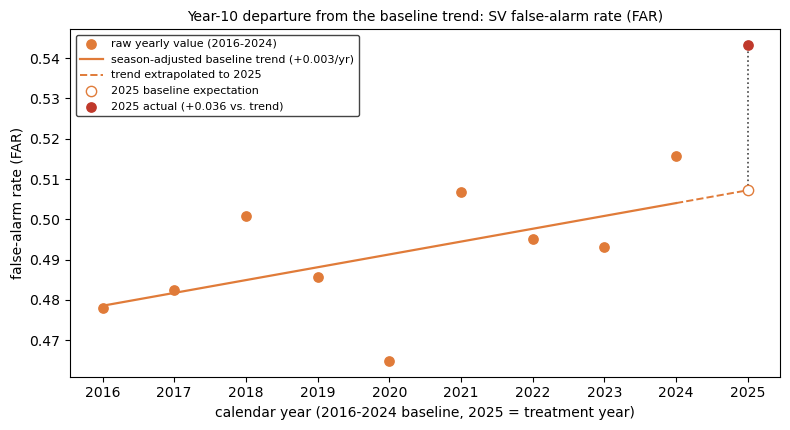

In [18]:
_y, _tr, _a = year10_inputs(sv_events, "false_alarm")
_d = stats.departure_summary(_tr, _a)
print(f"year-10 actual={_d['actual']:.4f}  trend@10={_d['trend_at_10']:.4f}  gap={_d['gap']:+.4f}")
plots.plot_year10_departure(_y, _tr, _a, "SV", "SV false-alarm rate (FAR)",
                            "false-alarm rate (FAR)", "far_sv", IMG_DIR)

*The year-10 false-alarm rate (0.543) rises above the extrapolated baseline trend (0.507), a gap of +0.036, meaning more false alarms than the trend predicts. This is the strongest single departure in the study: odds ratio 1.15, p < 0.001 (false-alarm odds up about 15 percent). Read with detection unchanged, the picture is more severe-storm warnings that did not verify, not fewer events being caught.*

### SV FAR placebo

The real year-10 verify-rate effect against the placebo spread from interior baseline years.

real=+0.1424  placebo spread=[-0.1108, +0.0813]  inside=False  placebo hits=4/7


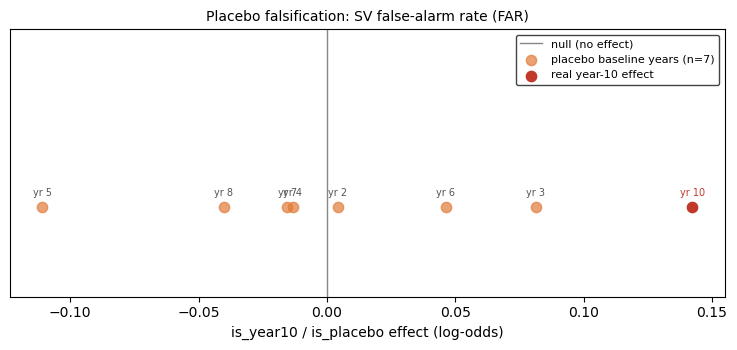

In [19]:
_pl = stats.run_placebo(sv_events, "false_alarm", "logit")
_real = next(r for r in RESULTS if r["event_type"] == "SV" and r["metric"] == "FAR")
_ps = stats.placebo_summary(_pl, _real["coef"])
print(f"real={_ps['real_coef']:+.4f}  placebo spread=[{_ps['lo']:+.4f}, {_ps['hi']:+.4f}]  "
      f"inside={_ps['inside']}  placebo hits={_ps['n_sig']}/{_ps['n']}")
plots.plot_placebo(_pl, _real["coef"], "SV", "SV false-alarm rate (FAR)",
                   "is_year10 / is_placebo effect (log-odds)", "far_sv", IMG_DIR)

*The real year-10 effect sits clearly above the placebo spread: no innocent baseline year produces a swing as large. This is the one metric where the placebo test supports treating year 10 as distinctive rather than ordinary baseline noise. Even so, the finding is associational, and reporting effort or year-10 weather composition remain rival explanations for a false-alarm-rate move.*

## Lead time (LTA)

Ordinary least squares (OLS) on warned severe-storm reports only; outcome `leadtime` in minutes. Lead time is conditional on detection, so this model sees only the events that were warned. The `is_year10` coefficient is already in minutes: the year-10 change in mean lead time relative to the season-adjusted baseline trend.

In [20]:
_ = report_fit("SV", "LTA", sv_warned, "leadtime", "ols")

SV LTA  (n=234,086)
  drift  study_year slope = +0.1467 minutes/yr [+0.1228, +0.1706]  p=0.0000
  YEAR10 is_year10 coef   = -0.1842 minutes [-0.4003, +0.0318]  p=0.0947 ns


### SV LTA year-10 departure

Mean lead time (minutes) per baseline year, the season-adjusted trend extrapolated to year 10, and the actual year-10 mean. Here both the figure and the OLS test are in minutes, so the drawn departure matches the test coefficient directly.

year-10 actual=23.266  trend@10=23.340  gap=-0.074 min


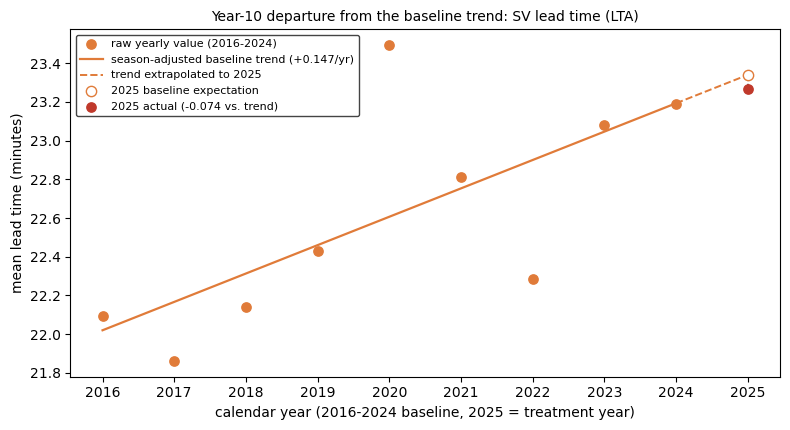

In [21]:
_y, _tr, _a = year10_inputs(sv_warned, "leadtime")
_d = stats.departure_summary(_tr, _a)
print(f"year-10 actual={_d['actual']:.3f}  trend@10={_d['trend_at_10']:.3f}  gap={_d['gap']:+.3f} min")
plots.plot_year10_departure(_y, _tr, _a, "SV", "SV lead time (LTA)",
                            "mean lead time (minutes)", "lta_sv", IMG_DIR)

*Mean lead time drifted upward across the baseline (+0.15 minutes per year). The year-10 actual (23.27 min) sits essentially on the extrapolated trend (23.34 min), a gap of -0.07 minutes, matching the non-significant test (-0.18 minutes, p = 0.09). No year-10 departure in severe-storm lead time. Lead time is conditional on detection, so a shift in which events were warned can move this mean independently of timeliness.*

### SV LTA placebo

The real year-10 lead-time effect (minutes) against the placebo spread from interior baseline years.

real=-0.184  placebo spread=[-0.774, +1.063] min  inside=True  placebo hits=3/7


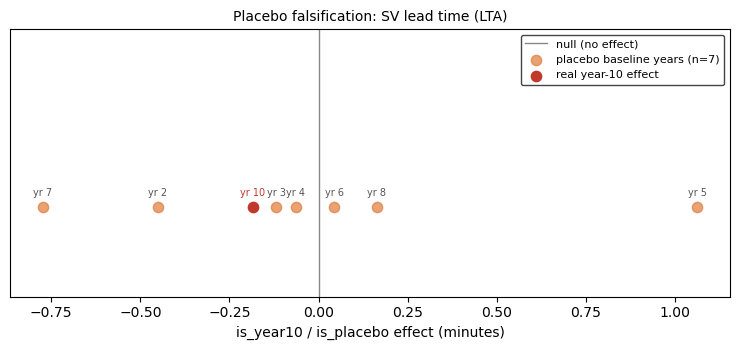

In [22]:
_pl = stats.run_placebo(sv_warned, "leadtime", "ols")
_real = next(r for r in RESULTS if r["event_type"] == "SV" and r["metric"] == "LTA")
_ps = stats.placebo_summary(_pl, _real["coef"])
print(f"real={_ps['real_coef']:+.3f}  placebo spread=[{_ps['lo']:+.3f}, {_ps['hi']:+.3f}] min  "
      f"inside={_ps['inside']}  placebo hits={_ps['n_sig']}/{_ps['n']}")
plots.plot_placebo(_pl, _real["coef"], "SV", "SV lead time (LTA)",
                   "is_year10 / is_placebo effect (minutes)", "lta_sv", IMG_DIR)

*The real year-10 effect sits inside the placebo spread, consistent with the near-zero departure above: no distinctive year-10 signal in severe-storm lead time.*

---

# Flash Flood (FF)

The three metrics for flash flood events, each fit separately. Flash-flood storm reports drive the detection (POD) and lead-time models; flash-flood warnings drive the false-alarm (FAR) model. The subset below is the only place the event-type filter is applied; every fit in this section reads from it.

The pre-modeling estimability gate (per-`season_cat` cell counts and 0%/100% separation checks) ran in `04_eda` over all nine fits and passed; it is not repeated here.

In [23]:
TYPE = "FF"

ff_reports = stormreports[stormreports["lsrtype"] == TYPE]
ff_events = events[events["phenomena"] == TYPE]
ff_warned = ff_reports[ff_reports["warned"] == 1]

print(f"{PHENOMENA_LABELS[TYPE]}:")
print(f"  storm reports : {len(ff_reports):,}  (POD model)")
print(f"  warnings      : {len(ff_events):,}  (FAR model)")
print(f"  warned reports: {len(ff_warned):,}  (lead-time model)")

Flash Flood:
  storm reports : 54,286  (POD model)
  warnings      : 38,828  (FAR model)
  warned reports: 42,529  (lead-time model)


## Probability of Detection (POD)

Logistic regression on flash-flood storm reports; outcome `warned` (was the observed event warned). First the drift check on baseline years 1 to 9 (`study_year` slope, diagnostic), then the main test on all ten years. The `is_year10` term, exponentiated to an odds ratio, is the quantity of interest: the year-10 departure from the season-adjusted baseline trend. Results are appended to `RESULTS` for the cross-cutting nine-test table later.

In [24]:
_ = report_fit("FF", "POD", ff_reports, "warned", "logit")

FF POD  (n=54,286)
  drift  study_year slope = -0.0094 log-odds/yr [-0.0178, -0.0009]  p=0.0306
  YEAR10 is_year10 coef   = +0.0434 log-odds [-0.0317, +0.1184]  p=0.2574 ns
         odds ratio       = 1.044 [0.969, 1.126]


### FF POD year-10 departure

The detection rate per baseline year (1 to 9), the season-adjusted trend fit on those years and extrapolated to year 10, and the actual year-10 rate. The dotted connector is the departure the test quantifies. The figure is on the rate scale for readability; the formal test above is on the odds-ratio scale and is not numerically identical.

year-10 actual=0.7952  trend@10=0.7740  gap=+0.0212


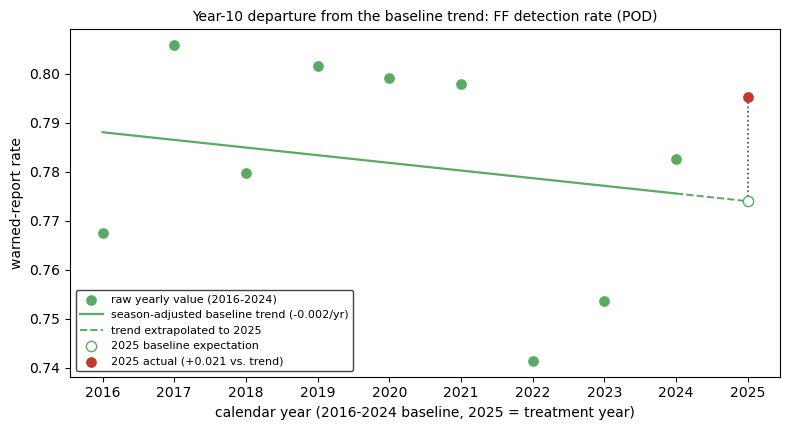

In [25]:
_y, _tr, _a = year10_inputs(ff_reports, "warned")
_d = stats.departure_summary(_tr, _a)
print(f"year-10 actual={_d['actual']:.4f}  trend@10={_d['trend_at_10']:.4f}  gap={_d['gap']:+.4f}")
plots.plot_year10_departure(_y, _tr, _a, "FF", "FF detection rate (POD)",
                            "warned-report rate", "pod_ff", IMG_DIR)

*The year-10 detection rate (0.795) sits modestly above the extrapolated baseline trend (0.774), a gap of +0.021 that is small against the noisy flash-flood baseline. This matches the non-significant test (odds ratio 1.04, p = 0.26): no year-10 departure in flash-flood detection. Note the baseline trend itself drifts slightly downward here (-0.009 log-odds per year), unlike the other two types.*

### FF POD placebo

The real year-10 effect against the spread of placebo effects from interior baseline years (year 10 dropped, a fake indicator substituted into each). If the real effect sits inside the placebo cloud, the method flags innocent years as readily as year 10. With only a handful of placebo years this is a rough credibility check, not a formal null.

real=+0.0434  placebo spread=[-0.2734, +0.1771]  inside=True  placebo hits=2/7


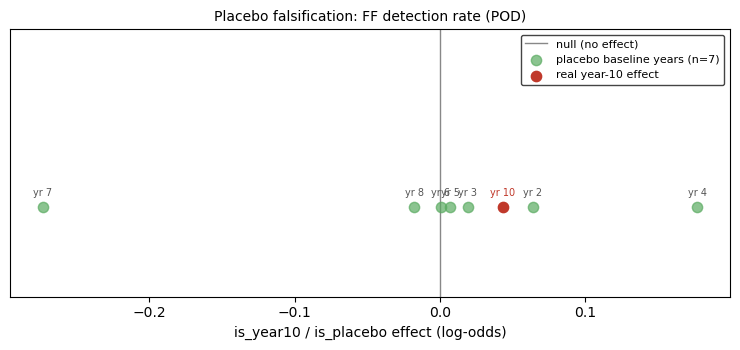

In [26]:
_pl = stats.run_placebo(ff_reports, "warned", "logit")
_real = next(r for r in RESULTS if r["event_type"] == "FF" and r["metric"] == "POD")
_ps = stats.placebo_summary(_pl, _real["coef"])
print(f"real={_ps['real_coef']:+.4f}  placebo spread=[{_ps['lo']:+.4f}, {_ps['hi']:+.4f}]  "
      f"inside={_ps['inside']}  placebo hits={_ps['n_sig']}/{_ps['n']}")
plots.plot_placebo(_pl, _real["coef"], "FF", "FF detection rate (POD)",
                   "is_year10 / is_placebo effect (log-odds)", "pod_ff", IMG_DIR)

*The real year-10 effect sits inside the placebo spread, so the method flags innocent baseline years about as readily as year 10. No distinctive year-10 signal in flash-flood detection.*

## False Alarm Ratio (FAR)

Logistic regression on flash-flood warnings; outcome `false_alarm` (1 = the warning did not verify against an observed event, i.e. it was a false alarm). FAR is the complement of the verification rate, `false_alarm = 1 - verify`, fit directly so the coefficient and odds ratio are on the false-alarm scale. A higher FAR means more false alarms. Same drift-then-main structure; the `is_year10` odds ratio is the year-10 departure in false-alarm odds from the baseline trend.

In [27]:
_ = report_fit("FF", "FAR", ff_events, "false_alarm", "logit")

FF FAR  (n=38,828)
  drift  study_year slope = +0.0310 log-odds/yr [+0.0227, +0.0394]  p=0.0000
  YEAR10 is_year10 coef   = -0.1351 log-odds [-0.2075, -0.0628]  p=0.0003 ***
         odds ratio       = 0.874 [0.813, 0.939]


### FF FAR year-10 departure

The false-alarm rate (FAR) per baseline year, the season-adjusted trend extrapolated to year 10, and the actual year-10 FAR. A higher rate means more false alarms. Rate scale for readability; the test above is on the odds-ratio scale.

year-10 actual=0.5559  trend@10=0.5873  gap=-0.0314


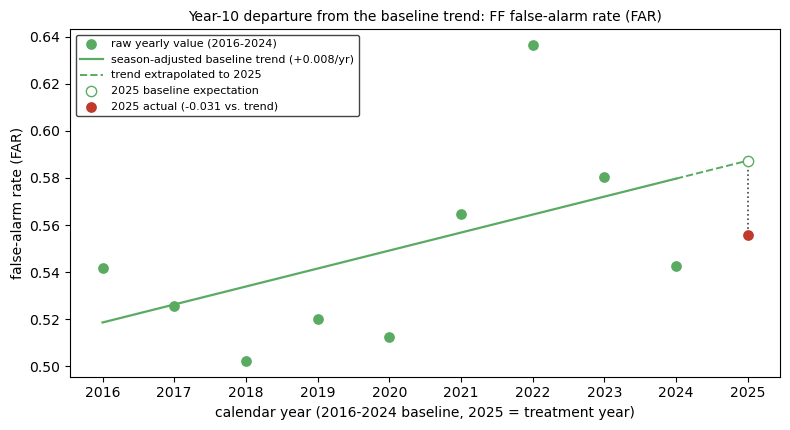

In [28]:
_y, _tr, _a = year10_inputs(ff_events, "false_alarm")
_d = stats.departure_summary(_tr, _a)
print(f"year-10 actual={_d['actual']:.4f}  trend@10={_d['trend_at_10']:.4f}  gap={_d['gap']:+.4f}")
plots.plot_year10_departure(_y, _tr, _a, "FF", "FF false-alarm rate (FAR)",
                            "false-alarm rate (FAR)", "far_ff", IMG_DIR)

*The year-10 false-alarm rate (0.556) sits below the extrapolated baseline trend (0.587), a gap of -0.031, meaning fewer false alarms than the trend predicts. The test is significant (odds ratio 0.87, p < 0.001), the opposite direction from the severe-storm FAR result. But the baseline trend is itself drifting up steeply (+0.031 log-odds per year toward more false alarms), so read the placebo check below before treating this as a year-10 event.*

### FF FAR placebo

The real year-10 verify-rate effect against the placebo spread from interior baseline years.

real=-0.1351  placebo spread=[-0.1683, +0.3456]  inside=True  placebo hits=4/7


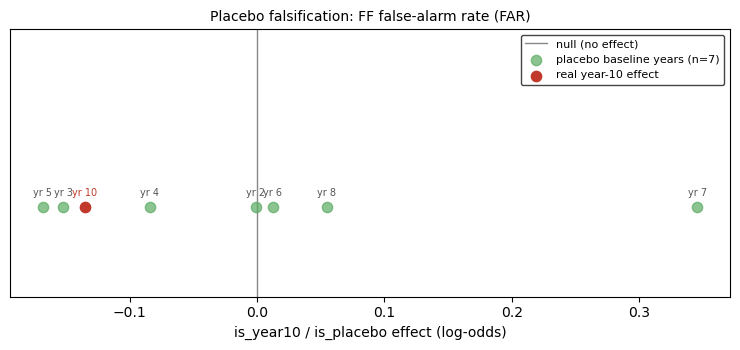

In [29]:
_pl = stats.run_placebo(ff_events, "false_alarm", "logit")
_real = next(r for r in RESULTS if r["event_type"] == "FF" and r["metric"] == "FAR")
_ps = stats.placebo_summary(_pl, _real["coef"])
print(f"real={_ps['real_coef']:+.4f}  placebo spread=[{_ps['lo']:+.4f}, {_ps['hi']:+.4f}]  "
      f"inside={_ps['inside']}  placebo hits={_ps['n_sig']}/{_ps['n']}")
plots.plot_placebo(_pl, _real["coef"], "FF", "FF false-alarm rate (FAR)",
                   "is_year10 / is_placebo effect (log-odds)", "far_ff", IMG_DIR)

*Despite the significant test, the real year-10 effect sits inside the placebo spread: interior baseline years produce swings just as large, and most come back significant too. The flash-flood false-alarm baseline is lumpy and steeply drifting, so the small p-value here reflects the big sample more than a distinctive year-10 change. Treat this result as exploratory, not as evidence of a year-10 shift.*

## Lead time (LTA)

Ordinary least squares (OLS) on warned flash-flood reports only; outcome `leadtime` in minutes. Lead time is conditional on detection, so this model sees only the events that were warned. The `is_year10` coefficient is already in minutes: the year-10 change in mean lead time relative to the season-adjusted baseline trend.

In [30]:
_ = report_fit("FF", "LTA", ff_warned, "leadtime", "ols")

FF LTA  (n=42,529)
  drift  study_year slope = +0.6127 minutes/yr [+0.2077, +1.0178]  p=0.0030
  YEAR10 is_year10 coef   = -12.9897 minutes [-16.4593, -9.5201]  p=0.0000 ***


### FF LTA year-10 departure

Mean lead time (minutes) per baseline year, the season-adjusted trend extrapolated to year 10, and the actual year-10 mean. Here both the figure and the OLS test are in minutes, so the drawn departure matches the test coefficient directly.

year-10 actual=92.218  trend@10=109.894  gap=-17.676 min


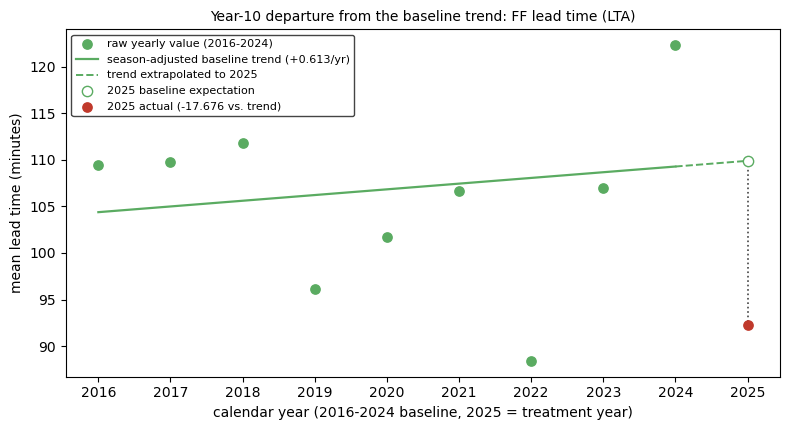

In [31]:
_y, _tr, _a = year10_inputs(ff_warned, "leadtime")
_d = stats.departure_summary(_tr, _a)
print(f"year-10 actual={_d['actual']:.3f}  trend@10={_d['trend_at_10']:.3f}  gap={_d['gap']:+.3f} min")
plots.plot_year10_departure(_y, _tr, _a, "FF", "FF lead time (LTA)",
                            "mean lead time (minutes)", "lta_ff", IMG_DIR)

*The year-10 mean lead time (92.2 min) falls far below the extrapolated baseline trend (109.9 min), a gap of about -18 minutes, the largest absolute departure in the study (test -13.0 minutes, p < 0.001). Two cautions temper it: flash-flood lead times are long and highly variable, so the baseline trend is steep and uncertain (+0.61 minutes per year), and lead time is conditional on detection, so a shift in which flash floods were warned can move this mean independently of timeliness. See the placebo check below.*

### FF LTA placebo

The real year-10 lead-time effect (minutes) against the placebo spread from interior baseline years.

real=-12.990  placebo spread=[-17.041, +10.355] min  inside=True  placebo hits=4/7


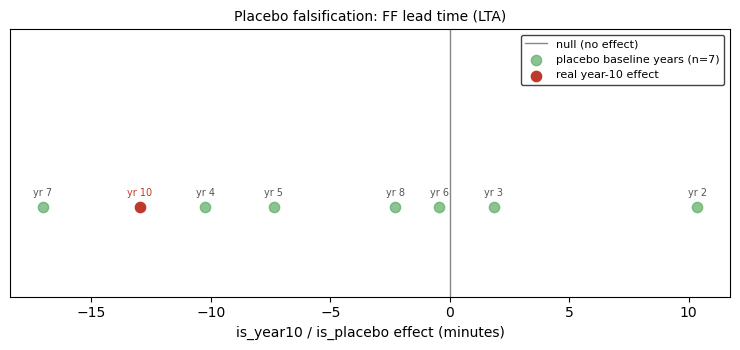

In [32]:
_pl = stats.run_placebo(ff_warned, "leadtime", "ols")
_real = next(r for r in RESULTS if r["event_type"] == "FF" and r["metric"] == "LTA")
_ps = stats.placebo_summary(_pl, _real["coef"])
print(f"real={_ps['real_coef']:+.3f}  placebo spread=[{_ps['lo']:+.3f}, {_ps['hi']:+.3f}] min  "
      f"inside={_ps['inside']}  placebo hits={_ps['n_sig']}/{_ps['n']}")
plots.plot_placebo(_pl, _real["coef"], "FF", "FF lead time (LTA)",
                   "is_year10 / is_placebo effect (minutes)", "lta_ff", IMG_DIR)

*Despite the large significant coefficient, the real year-10 effect sits inside the placebo spread: an interior baseline year swings as far. The flash-flood lead-time baseline is volatile enough that an 18-minute move is within its ordinary year-to-year range, so this departure should be read as exploratory rather than a distinctive year-10 signal.*

---

# Checkpoint: the nine tests read as a family

Each `is_year10` term above was fit and read on its own. Read together they form a family of nine tests (three metrics times three event types), and the raw per-test p-values overstate how many departures are real once nine are inspected at once. This section assembles the nine `is_year10` results, applies the Benjamini-Hochberg false-discovery-rate (FDR) correction across the whole family, and shows which departures survive. The correction is the multiple-comparison safeguard the design calls for: tests that do not clear it after correction are read as exploratory, not as established year-10 changes. The placebo checks above are the second filter; a departure is only persuasive if it both survives FDR and stands outside its placebo spread.

In [33]:
SYNTH = stats.synthesis_table(RESULTS)

# Readable view: native-scale coefficient, odds ratio where applicable, raw and FDR p-values.
_view = SYNTH.assign(
    coef=SYNTH["coef"].round(3),
    or_=SYNTH["or"].round(3),
    p_raw=SYNTH["p"].round(4),
    p_fdr=SYNTH["p_fdr"].round(4),
)[["event_type", "metric", "kind", "n", "coef", "or_", "p_raw", "p_fdr", "survives", "stars"]]
print(_view.to_string(index=False))
print(f"\nsurvive FDR (q < 0.05): {int(SYNTH['survives'].sum())} of {len(SYNTH)} tests")

event_type metric  kind      n    coef   or_  p_raw  p_fdr  survives stars
        TO    POD logit  17510   0.087 1.091 0.1675 0.2513     False    ns
        TO    FAR logit  25817   0.031 1.031 0.5552 0.5552     False    ns
        TO    LTA   ols  11217  -0.595   NaN 0.1479 0.2513     False    ns
        SV    POD logit 305167   0.015 1.015 0.3663 0.4121     False    ns
        SV    FAR logit 195892   0.142 1.153 0.0000 0.0000      True   ***
        SV    LTA   ols 234086  -0.184   NaN 0.0947 0.2131     False    ns
        FF    POD logit  54286   0.043 1.044 0.2574 0.3309     False    ns
        FF    FAR logit  38828  -0.135 0.874 0.0003 0.0008      True   ***
        FF    LTA   ols  42529 -12.990   NaN 0.0000 0.0000      True   ***

survive FDR (q < 0.05): 3 of 9 tests


*Three of the nine tests survive the FDR correction (q < 0.05): severe-storm FAR, flash-flood FAR, and flash-flood LTA. The other six, including all three detection (POD) tests and every tornado test, do not. But surviving FDR is only the first filter. Of the three survivors, two (flash-flood FAR and flash-flood LTA) sit inside their placebo spreads above, where interior baseline years swing just as far, so their small p-values reflect the enormous sample and a lumpy, steeply drifting flash-flood baseline rather than a distinctive year-10 event. Only severe-storm FAR clears both filters: it survives FDR and stands clearly outside its placebo spread. That single result, more severe-storm warnings that did not verify with detection unchanged, is the one departure this study treats as credible rather than exploratory, and it remains associational.*

### Forest plot: the six binary departures (log-odds)

The `is_year10` coefficient and 95 percent confidence interval for the six logistic tests (POD and FAR across the three event types), all on the log-odds scale so they share one axis. The null line at zero is no year-10 departure; a filled marker survives the FDR correction, a hollow one does not. Lead time is on a different scale (minutes) and gets its own figure below, never mixed onto this axis.

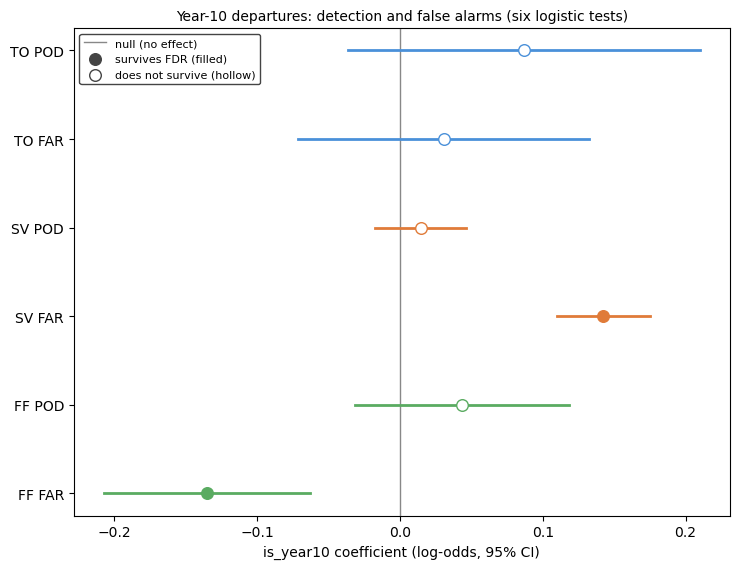

In [34]:
plots.plot_year10_forest(
    SYNTH[SYNTH["kind"] == "logit"], "logit",
    "Year-10 departures: detection and false alarms (six logistic tests)",
    "is_year10 coefficient (log-odds, 95% CI)", "binary", IMG_DIR)

*The four detection and tornado intervals straddle zero, the visual form of their non-significant tests. The two FAR survivors sit off zero in opposite directions: severe-storm FAR is positive (higher false-alarm odds, more false alarms) and flash-flood FAR is negative (fewer false alarms). Both are drawn filled because both survive FDR, but only severe-storm FAR also stood outside its placebo spread, so the filled flash-flood FAR marker should still be read as exploratory.*

### Forest plot: the three lead-time departures (minutes)

The `is_year10` coefficient and 95 percent confidence interval for the three lead-time tests, on the minutes scale. Drawn separately from the binary tests because the scale differs: here the coefficient is already a change in mean lead time in minutes. Same encoding: null line at zero, a filled marker survives FDR, a hollow one does not.

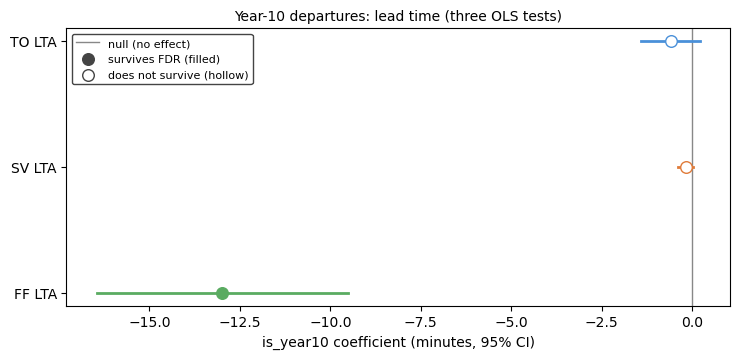

In [35]:
plots.plot_year10_forest(
    SYNTH[SYNTH["kind"] == "ols"], "ols",
    "Year-10 departures: lead time (three OLS tests)",
    "is_year10 coefficient (minutes, 95% CI)", "lta", IMG_DIR)

### All nine placebo tests on one standardized scale

The per-metric placebo figures above each live on their own native scale (log-odds for detection and false alarms, minutes for lead time), so they cannot be compared side by side. This figure puts all nine tests on one axis by standardizing every effect to its Wald statistic (coefficient divided by standard error), which is unitless and shares the same plus or minus 1.96 significance reference across the logistic and ordinary least squares (OLS) fits. Each row is one event-type by metric cell: grey points are the placebo baseline years, the colored diamond is the real year-10 effect. A diamond outside both its grey placebo cloud and the shaded band is the distinctive, credible case; one inside the cloud is flagged about as readily as an innocent baseline year. The nine placebo tables are recomputed here from the same event-type subsets used above so the cell is self-contained.

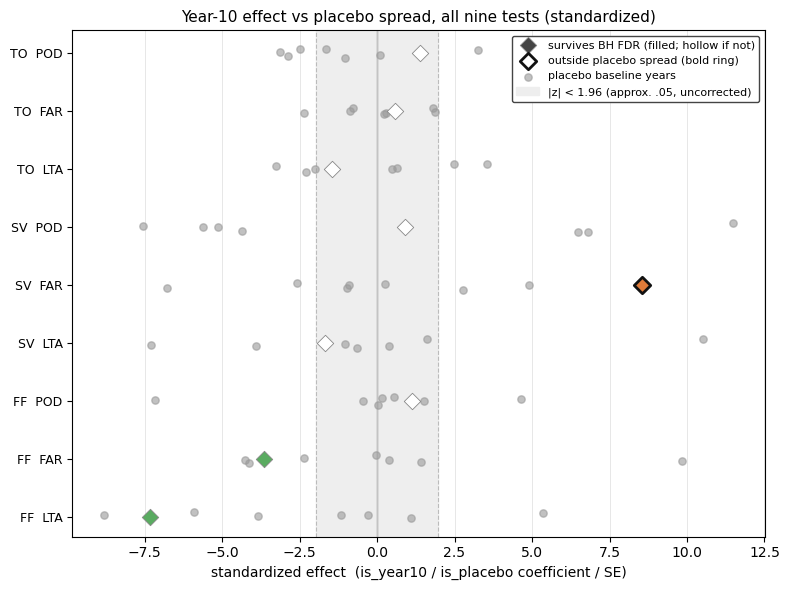

In [36]:
# Recompute the nine placebo tables from the persisted event-type subsets, pair each
# with its real year-10 fit (carrying se) from RESULTS and its BH-FDR survival from
# SYNTH, and standardize to coef/SE for the consolidated figure.
_placebo_specs = [
    ("TO", "POD", to_reports, "warned",      "logit"),
    ("TO", "FAR", to_events,  "false_alarm", "logit"),
    ("TO", "LTA", to_warned,  "leadtime",    "ols"),
    ("SV", "POD", sv_reports, "warned",      "logit"),
    ("SV", "FAR", sv_events,  "false_alarm", "logit"),
    ("SV", "LTA", sv_warned,  "leadtime",    "ols"),
    ("FF", "POD", ff_reports, "warned",      "logit"),
    ("FF", "FAR", ff_events,  "false_alarm", "logit"),
    ("FF", "LTA", ff_warned,  "leadtime",    "ols"),
]
_survives = {(r["event_type"], r["metric"]): bool(r["survives"])
             for _, r in SYNTH.iterrows()}
_cells = []
for _ev, _metric, _df, _outcome, _kind in _placebo_specs:
    _real = next(r for r in RESULTS if r["event_type"] == _ev and r["metric"] == _metric)
    _cells.append({"event": _ev, "metric": _metric,
                   "placebo": stats.run_placebo(_df, _outcome, _kind),
                   "main": _real,
                   "survives_fdr": _survives[(_ev, _metric)]})
_norm = stats.standardized_placebo_frame(_cells)
plots.plot_placebo_normalized(_norm, IMG_DIR)

*Read on the standardized axis, only severe-storm FAR stands clearly to the right of both its placebo cloud and the plus or minus 1.96 band; the other eight year-10 diamonds sit inside their grey placebo spreads and, mostly, inside the band. This is the same conclusion the per-cell placebo checks and the FDR-corrected table reached, now visible across all nine tests at once: severe-storm FAR is the lone departure that is both significant and distinctive from innocent baseline years. The axis is the raw signed Wald statistic, so a positive value means a positive coefficient, whose performance meaning differs by metric (higher detection is better, higher false-alarm rate is worse, longer lead time is better); direction is not aligned to performance. The finding remains associational.*

*Tornado and severe-storm lead-time intervals straddle zero (non-significant). The flash-flood interval sits far to the left (about -13 minutes) and is drawn filled because it survives FDR, but the interval is wide, reflecting the volatile flash-flood lead-time baseline, and the effect sat inside its placebo spread above. So this large, FDR-surviving departure is still read as exploratory: the year-10 move is within the ordinary year-to-year range for flash-flood lead time.*

# Office-level heterogeneity: did some offices change while others did not?

Everything above is national. Each of the nine tests pools rows across all in-scope offices, so the `is_year10` term is the year-10 departure of the volume-weighted national rate. The exploratory data analysis (EDA) showed that event volume is unevenly distributed. This section asks, “Does the year-10 effect vary across offices at all?”.

For each metric and event type we fit an office-fixed-effects model with a per-office year-10 interaction, `outcome ~ C(season_cat) + study_year + C(wfo) + C(wfo):is_year10`, with standard errors clustered on office (WFO) so the per-office estimates carry within-office storm clustering, and the lead-time (LTA) outcome on the `sqrt(leadtime)` scale settled on in `04_eda`. The deliverable is descriptive: the **spread** of the per-office year-10 effects (reported as an odds-ratio multiplier for the binary metrics, sqrt-minutes for lead time). Wide spread says offices did not move together in year 10; near-zero spread says a single shared national effect describes them well. We do not attempt a formal joint test of the interaction block. A cluster-robust Wald test over per-office terms clustered on the same office is rank-deficient and its p-value would be invalid, so a rigorous heterogeneity test is left to a future study. What we want here is a signal pointing toward where to look, not a tested claim.

Two cautions shape how this is read, and why we stop at the spread. First, the spread is a description of the point estimates, not a significance test, so read it as a direction of inquiry rather than an established effect. Second, the fit can only include offices whose year-10 cell is well sampled (at least 20 year-10 rows and, for the binary metrics, a non-degenerate rate); the kept-versus-total office count is reported and is itself the evidence for the scope limit. **Naming which offices moved is a separate question that this design cannot answer reliably**, because per-office year-10 estimates are too sparse, acutely so for tornado, where most offices are dropped for want of data. A per-office heterogeneity map is therefore named here as future work, not attempted: it needs more years of data per office, and to move from association to attribution it needs the per-office staffing data this study does not have. The finding stays associational throughout: even a clearly heterogeneous result says the year-10 response varied by office, not why.

In [37]:
# One office-heterogeneity fit per metric x event type.
# The spread of per-office year-10 effects is the deliverable: a descriptive signal of
# where to direct further inquiry, not a tested claim (no valid joint test at this design).
HETERO_SPECS = [
    ("TO", "POD", to_reports, "warned",      "logit"),
    ("TO", "FAR", to_events,  "false_alarm", "logit"),
    ("TO", "LTA", to_warned,  "leadtime",    "ols"),
    ("SV", "POD", sv_reports, "warned",      "logit"),
    ("SV", "FAR", sv_events,  "false_alarm", "logit"),
    ("SV", "LTA", sv_warned,  "leadtime",    "ols"),
    ("FF", "POD", ff_reports, "warned",      "logit"),
    ("FF", "FAR", ff_events,  "false_alarm", "logit"),
    ("FF", "LTA", ff_warned,  "leadtime",    "ols"),
]

_rows = []
for et, metric, df, outcome, kind in HETERO_SPECS:
    h = stats.fit_office_heterogeneity(df, outcome, kind)
    _rows.append({
        "event_type": et, "metric": metric,
        "offices_kept": f"{h['n_offices_kept']}/{h['n_offices_total']}",
        "n": h["n"],
        # Spread on the interpretable scale: OR multiplier for logit, sqrt-min SD for OLS.
        "spread": round(h["effect_sd_or"], 2) if kind == "logit" else round(h["effect_sd"], 2),
        "spread_scale": "OR/SD" if kind == "logit" else "sqrt-min SD",
    })

HETERO = pd.DataFrame(_rows)
print(HETERO.to_string(index=False, float_format=lambda x: f"{x:.2g}"))

event_type metric offices_kept      n  spread spread_scale
        TO    POD       33/116  11168     2.3        OR/SD
        TO    FAR       44/113  17859       2        OR/SD
        TO    LTA       24/103   5914    0.49  sqrt-min SD
        SV    POD      103/116 302653     1.7        OR/SD
        SV    FAR      105/116 194538     1.6        OR/SD
        SV    LTA       98/116 232698    0.37  sqrt-min SD
        FF    POD       65/115  45617       2        OR/SD
        FF    FAR       66/115  32975     1.7        OR/SD
        FF    LTA       55/113  35715     1.8  sqrt-min SD


*Across all nine metric-by-event-type combinations the per-office year-10 effects show meaningful spread: offices did not move together in year 10. Across offices the year-10 effect ranges over roughly a 1.5 to 2.3 times odds-ratio band for the detection and false-alarm metrics, and lead time is likewise dispersed across offices on its own sqrt-minute scale (the two scales are not directly comparable). The spread is most credible for severe storm, where 100-plus offices are retained; the tornado spreads rest on a quarter of offices and are correspondingly noisier. This is a descriptive signal pointing toward the office dimension as where the year-10 variation lives, not a tested claim; a formal heterogeneity test is left to a future study.*

### Office spread: detection (POD)

The table reports each cell's spread as one number. This figure shows the scatter behind it for detection: one row per event type, each a strip of the kept offices' year-10 detection effects on the odds-ratio scale (above 1 means that office detected more in year 10 than its baseline trend predicts, below 1 means less). The vertical line at odds ratio 1 is no departure; the diamond is the median office; each row is labelled with how many offices it rests on. Read it as the dispersion the spread number summarizes, not a test: a wide, asymmetric cloud is the visual form of "offices did not move together".

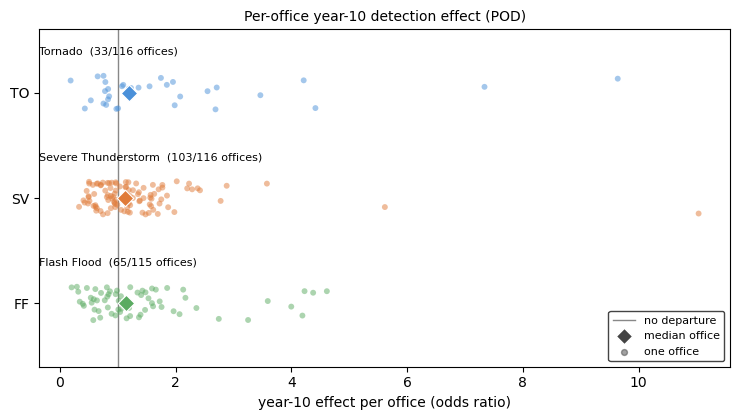

In [38]:
_pod = {et: stats.fit_office_heterogeneity(d, "warned", "logit")
        for et, d in [("TO", to_reports), ("SV", sv_reports), ("FF", ff_reports)]}
plots.plot_office_spread(_pod, "logit", "POD",
                         "Per-office year-10 detection effect (POD)",
                         "year-10 effect per office (odds ratio)", IMG_DIR)

*The detection clouds straddle the no-departure line with a long right tail: most offices sit near odds ratio 1, but a handful detected much more in year 10 (out to 5 to 11 times the baseline-trend odds). The median office is close to 1 for all three types, so the central tendency is "no change" while the spread lives in the tail. Tornado rests on only 33 of 116 offices, so its cloud is the thinnest and least trustworthy; severe storm (103 offices) is the most credible.*

### Office spread: false alarms (FAR)

The same view for false alarms: each office's year-10 false-alarm effect on the odds-ratio scale (above 1 means more false alarms in year 10 than the baseline trend predicts). Line at 1 is no departure, diamond is the median office, row labels carry the kept-office count.

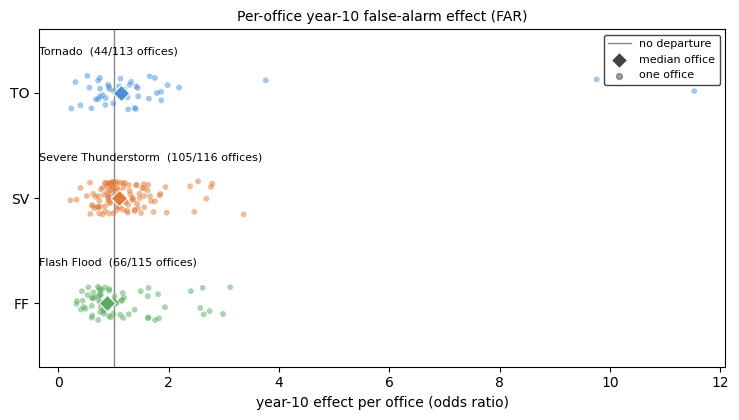

In [39]:
_far = {et: stats.fit_office_heterogeneity(d, "false_alarm", "logit")
        for et, d in [("TO", to_events), ("SV", sv_events), ("FF", ff_events)]}
plots.plot_office_spread(_far, "logit", "FAR",
                         "Per-office year-10 false-alarm effect (FAR)",
                         "year-10 effect per office (odds ratio)", IMG_DIR)

The strip plot above compresses all three event types into jittered rows, which hides the shape of any single one. Severe-storm false alarms (FAR) is the one credible national departure, so it earns a closer look on its own. This figure histograms the per-office year-10 false-alarm effects for severe storm alone (odds-ratio scale), with two reference lines: odds ratio 1 (no departure) and the national year-10 odds ratio. The question is where the national finding sits relative to the office cloud: if it lands among the offices rather than out in a tail, the national rise is broad rather than the work of a few outliers. As before this is descriptive: it pictures the spread of the per-office point estimates, not a test that the spread exceeds noise.

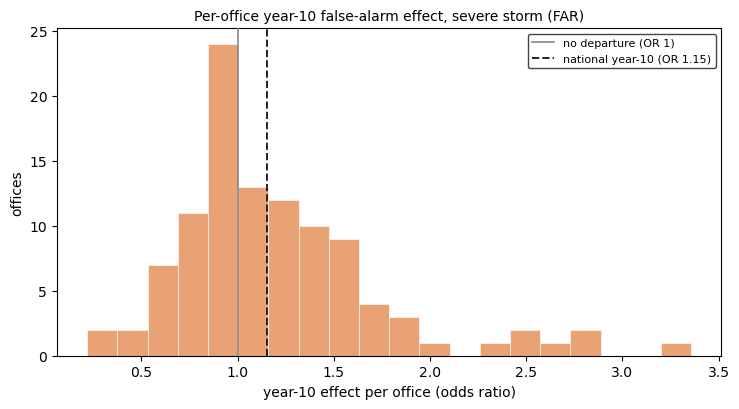

In [40]:
# Per-office year-10 false-alarm effects for severe storm alone, as a distribution.
# Reuses the SV cell already fit for the strip plot (_far["SV"]); the national odds
# ratio is pulled live from the SV-FAR record in RESULTS so it cannot drift.
_sv_far_or = next(r for r in RESULTS if r["event_type"] == "SV" and r["metric"] == "FAR")["or"]
plots.plot_office_effect_hist(_far["SV"]["office_effects"], "SV", _sv_far_or,
                              "Per-office year-10 false-alarm effect, severe storm (FAR)",
                              "year-10 effect per office (odds ratio)",
                              "office_effect_hist_far_sv", IMG_DIR)

*The per-office severe-storm false-alarm effects are right-skewed: the densest bin sits just below odds ratio 1, but more offices fall above 1 than below (about 58 percent), with a thin tail running past 3. The median office (odds ratio about 1.10) and the national year-10 rise (about 1.15) nearly coincide, so the national finding reflects a broad rightward shift across many offices rather than one outlier office dragging the average. This remains descriptive, not a tested claim: it shows where the per-office estimates sit, not that the office-to-office spread exceeds what sampling noise alone would produce.*

*The false-alarm clouds are tighter than detection (the severe-storm spread is the smallest of the nine cells), but still clearly dispersed and right-skewed. Severe storm, the one metric whose national false-alarm result survived both filters earlier, shows its national rise as a cloud sitting mostly above 1 across many offices rather than one office driving it. Tornado again rests on few offices and should be read loosely.*

### Office spread: lead time (LTA)

The lead-time view is on the minutes scale, not odds ratios: each office's year-10 lead-time effect in minutes (above 0 means longer lead time in year 10 than the baseline trend predicts, below 0 means shorter). The reference line is at 0 minutes, the diamond is the median office, and the effects are back-transformed from the `sqrt(leadtime)` scale the model was fit on, so the per-office spacing is on the minute scale a reader interprets.

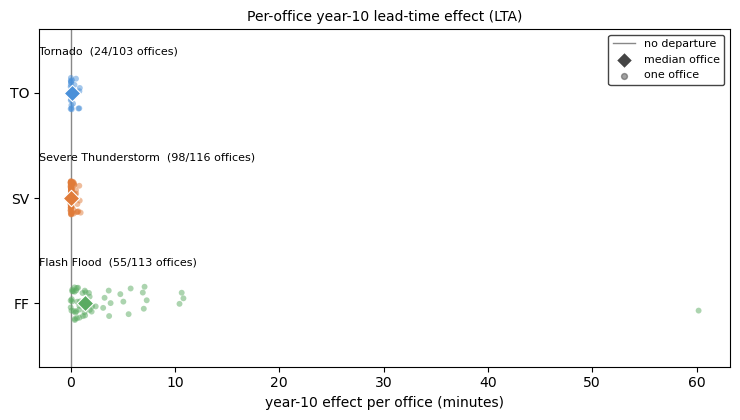

In [41]:
_lta = {et: stats.fit_office_heterogeneity(d, "leadtime", "ols")
        for et, d in [("TO", to_warned), ("SV", sv_warned), ("FF", ff_warned)]}
plots.plot_office_spread(_lta, "ols", "LTA",
                         "Per-office year-10 lead-time effect (LTA)",
                         "year-10 effect per office (minutes)", IMG_DIR)

*Lead-time effects scatter on both sides of zero by a few minutes for tornado and severe storm, with flash flood the widest by far, consistent with its volatile, long lead times and the large national flash-flood lead-time move seen earlier. As with the other metrics the median office is near no-change and the action is in the spread. Flash flood rests on 55 offices and tornado on 24, so the flash-flood width is better supported than the tornado scatter.*

### SV FAR: did warning size change too? (exploratory diagnostic)

The severe-storm false-alarm result above is the one credible year-10 departure. A natural follow-on question is *how* the warning behavior differs: when more severe-storm warnings failed to verify in year 10, were the warnings also drawn larger? The events table carries warning polygon area (`carea`, in square kilometers), and the cleaning notes flag it as a speculative-warning proxy ("larger warnings tend to be more precautionary").

This is a **diagnostic that characterizes the existing FAR finding, not a tenth formal test**. It is exploratory and is deliberately kept out of the nine false-discovery-rate-corrected (FDR) tests. It stays associational and cannot separate a genuine behavior change (offices drawing larger warnings) from the documented year-10 geographic footprint shift (different weather covering larger areas); that is the same rival explanation one level down, since polygon size is downstream of the weather.

The fit is on `log(carea)`. The area distribution is heavily right-skewed (the severe-storm mean is well above the median), so the log scale keeps the ordinary least squares (OLS) residuals sound and lets the `is_year10` coefficient read as an approximate percent departure. It uses the same structure as the main tests, `log(carea) ~ C(season_cat) + study_year + is_year10`, on severe-storm warnings across all ten study years.

In [42]:
# Exploratory diagnostic (NOT one of the nine FDR-corrected tests): does severe-storm
# warning area depart from its season-adjusted baseline trend in year 10? Fit on
# log(carea) so the is_year10 coefficient reads as an approximate percent departure.
_sv_carea = sv_events.copy()
_sv_carea["log_carea"] = np.log(_sv_carea["carea"])

_drift = stats.fit_drift(_sv_carea, "log_carea", "ols")
_main = stats.fit_main_model(_sv_carea, "log_carea", "ols")
_pct = lambda c: (np.exp(c) - 1) * 100   # log coefficient -> approximate percent

print(f"SV warning area (carea), exploratory  (n={_main['n']:,})")
print(f"  drift  study_year slope = {_pct(_drift['slope']):+.2f}%/yr  p={_drift['p']:.4f}")
print(f"  YEAR10 is_year10 coef   = {_pct(_main['coef']):+.1f}% "
      f"[{_pct(_main['ci_low']):+.1f}%, {_pct(_main['ci_high']):+.1f}%]  "
      f"p={_main['p']:.4f} {stats.sig_stars(_main['p'])}")

SV warning area (carea), exploratory  (n=195,892)
  drift  study_year slope = +1.00%/yr  p=0.0000
  YEAR10 is_year10 coef   = +4.1% [+2.9%, +5.4%]  p=0.0000 ***


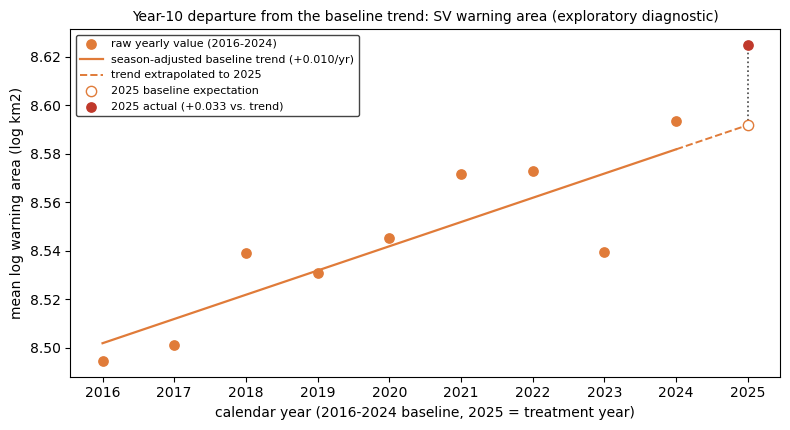

In [43]:
# Single-panel figure on the log(carea) scale, self-consistent with the fit: per-year
# mean log-area (study years 1-9) scattered, the season-adjusted baseline trend overlaid
# and extended to year 10, the actual year-10 mean marked. The gap is the is_year10
# departure drawn rather than tabulated. Log scale because carea is heavily right-skewed,
# so a mean-fit line on raw km2 would not sit among the points.
_y = _sv_carea[_sv_carea["study_year"] < 10].groupby("study_year")["log_carea"].mean()
_tr = stats.season_adjusted_trend(_sv_carea, "log_carea")
_a = float(_sv_carea[_sv_carea["study_year"] == 10]["log_carea"].mean())
plots.plot_year10_departure(_y, _tr, _a, "SV",
                            "SV warning area (exploratory diagnostic)",
                            "mean log warning area (log km2)", "carea_sv", IMG_DIR)

*Severe-storm warning area departs upward in year 10: about +4% above the season-adjusted baseline trend (p < 0.001), on top of a roughly +1%/yr baseline drift that the `study_year` term already absorbs. So year 10's warnings were drawn modestly larger than the trend predicts, in the same direction as the year-10 rise in false alarms above; bigger, more precautionary polygons are consistent with more warnings that did not verify. This is descriptive, not a test of cause, and is not one of the nine FDR-corrected tests. The same caution as the false-alarm finding applies and binds harder here: warning area is directly downstream of the weather, so the documented year-10 geographic footprint shift is a live rival explanation for a larger-warning year. The diagnostic shows the FAR move is accompanied by a size move; it does not establish that offices changed how they warn.*